# 1. Import thư viện

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

from metrics import manual_silhouette_score, manual_davies_bouldin_score, manual_calinski_harabasz_score
from model import AgglomerativeClusteringCustom

# 2. DATA
## 2.1 Load dữ liệu
## 2.2 Kiểm tra mising value
## 2.3 Chuẩn hoá dữ liệu

In [2]:
# 1. Load dữ liệu
data = load_iris()
X = data.data
y_true = data.target

df = pd.DataFrame(X, columns=data.feature_names)

print("Shape:", df.shape)
print(df.head())

# 2. Kiểm tra dữ liệu
print("\nMissing values:\n", df.isnull().sum())

# 3. Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Shape: (150, 4)
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Missing values:
 sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64


In [3]:
df = pd.DataFrame(data.data, columns=data.feature_names)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


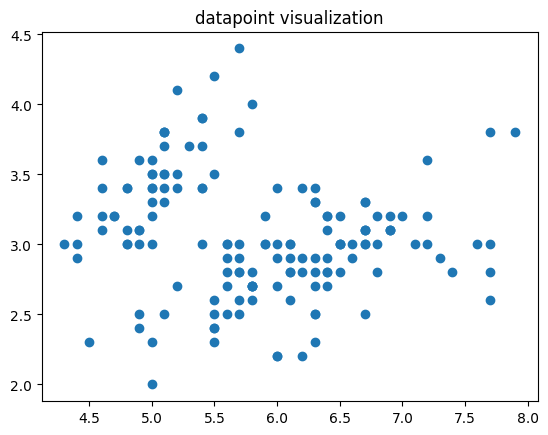

In [4]:
plt.scatter(X[:, 0], X[:, 1])
plt.title("datapoint visualization")
plt.show()

# 3. Khởi tạo mô hình & tìm số cụm tối ưu

In [5]:
for n_clusters in range(2, 11):
    model = AgglomerativeClusteringCustom(
        n_clusters=n_clusters
    )

    labels = model.fit_predict(X_scaled)

    sil = manual_silhouette_score(X_scaled, labels)
    db  = manual_davies_bouldin_score(X_scaled, labels)
    ch  = manual_calinski_harabasz_score(X_scaled, labels)
    
    print(f"k={n_clusters} | Silhouette={sil:.4f} | DB={db:.4f} | CH={ch:.4f}")


k=2 | Silhouette=0.4407 | DB=0.8927 | CH=151.6332
k=3 | Silhouette=0.4495 | DB=0.7584 | CH=213.0817
k=4 | Silhouette=0.4104 | DB=0.8768 | CH=183.9682
k=5 | Silhouette=0.3519 | DB=0.8584 | CH=166.6596
k=6 | Silhouette=0.3105 | DB=0.8824 | CH=144.2243
k=7 | Silhouette=0.3074 | DB=0.7948 | CH=131.9862
k=8 | Silhouette=0.3301 | DB=0.8783 | CH=149.0463
k=9 | Silhouette=0.3415 | DB=0.9118 | CH=150.1464
k=10 | Silhouette=0.3261 | DB=0.9198 | CH=166.4470


# Nhậm thấy k=3 cho Silhouette Score cao nhất
## -> số cụm tối ưu là 3

In [7]:
best_model = AgglomerativeClusteringCustom(n_clusters=3)
labels = best_model.fit_predict(X_scaled)

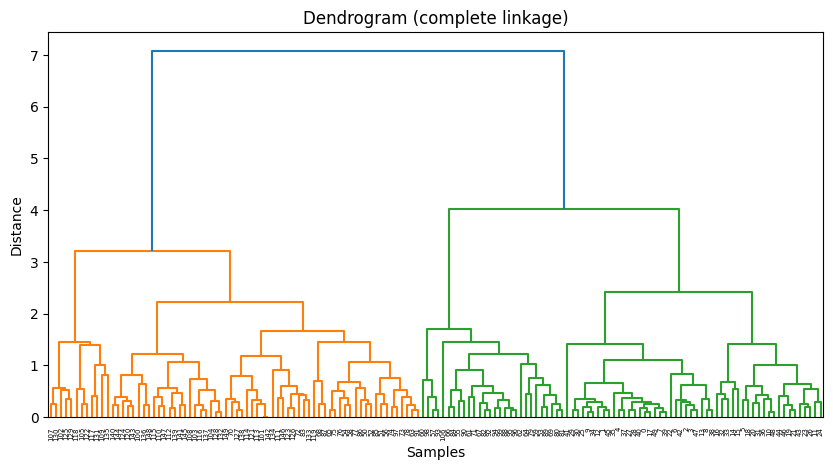

In [8]:
def plot_dendrogram(X, method="complete"):
    """
    Vẽ dendrogram cho hierarchical clustering
    """
    Z = linkage(X, method=method)

    plt.figure(figsize=(10, 5))
    dendrogram(Z)
    plt.title(f"Dendrogram ({method} linkage)")
    plt.xlabel("Samples")
    plt.ylabel("Distance")
    plt.show()

plot_dendrogram(X)

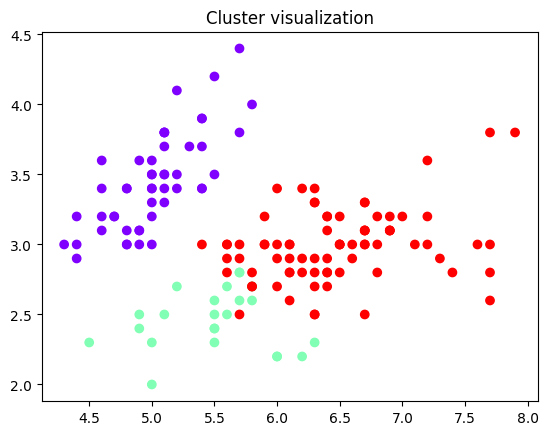

In [9]:
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='rainbow')
plt.title("Cluster visualization")
plt.show()

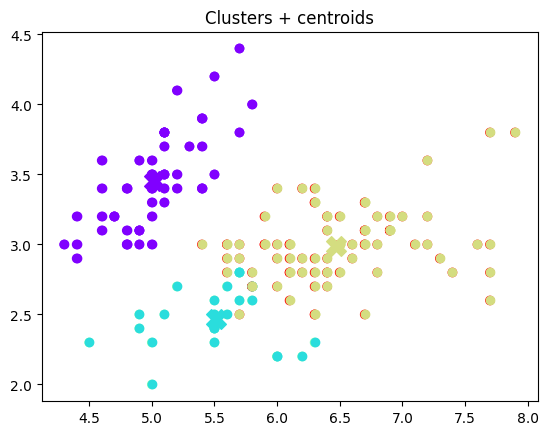

In [10]:
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='rainbow')
for c in np.unique(labels):
    points = X[labels == c]
    centroid = points.mean(axis=0)
    
    color = plt.cm.rainbow(c / len(np.unique(labels)))
    
    plt.scatter(points[:, 0], points[:, 1], color=color)
    plt.scatter(centroid[0], centroid[1], s=200, marker='X', color=color)

plt.title("Clusters + centroids")
plt.show()

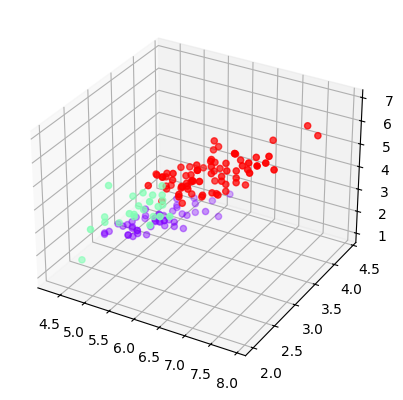

In [11]:

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=labels, cmap='rainbow')

plt.show()


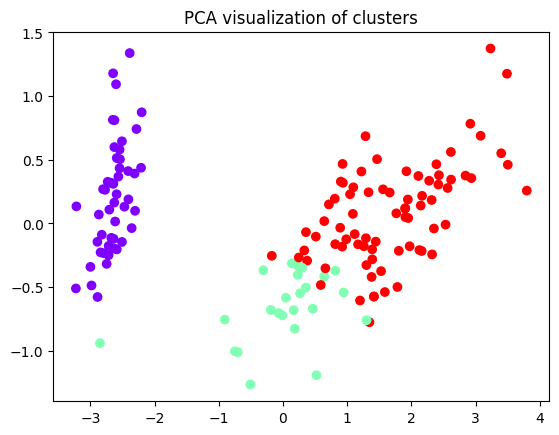

In [12]:
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap='rainbow')
plt.title("PCA visualization of clusters")
plt.show()